# **NYC Regents Exam Pass Prediction 🎓**

**Predicting whether NYC students will pass (score ≥65) their Regents exams using school-level metadata.**

### **What this notebook covers:**
1. Loading & understanding the NYC Regents Exam Results dataset
2. Data cleaning (handling suppressed/missing values)
3. Exploratory Data Analysis (EDA)
4. Feature engineering & leakage-free target creation
5. Model building (Random Forest, XGBoost, LightGBM)
6. Model evaluation & comparison
7. Conclusion

**Dataset:** 2014-15 to 2017-19 NYC Regents Exam Results (Public) — ~33K rows covering NYC school Regents exam performance by year, subject, and school.


## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_style('whitegrid')
%matplotlib inline


## **2. Load the Dataset**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/razanihababdellatif/nyc-regents-exam-dataset/2014-15_to_2017-19_NYC_Regents_Exam_Results_-_Public_20260724.csv', low_memory=False)
print("Shape:", df.shape)
df.head()


Shape: (33031, 18)


,Unnamed Column,School DBN,School Name,School Type,School Level,Regents Exam,Year,Category,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,08X5072015All StudentsGeometry,08X507,Stevenson Yabc,YABC,High school,Geometry,2015,All Students,1,s,s,s,s,s,s,s,s,s
1,01M1842018All StudentsLiving Environment,01M184,P.S. 184m Shuang Wen,General Academic,K-8,Living Environment,2018,All Students,32,90.2,0,0.0,32,100.0,31,96.9,na,na
2,01M4582019All StudentsSpanish,01M458,Forsyth Satellite Academy,Transfer School,High school,Spanish,2019,All Students,1,s,s,s,s,s,s,s,s,s
3,01M5092017All StudentsSpanish,01M509,Marta Valle High School,General Academic,High school,Spanish,2017,All Students,16,82.7,0,0.0,16,100.0,10,62.5,na,na
4,02M2982015All StudentsGeometry,02M298,Pace High School,General Academic,High school,Geometry,2015,All Students,163,62.9,81,49.7,82,50.3,13,8.0,13,8.0


## **3. Data Overview**

Let's understand the columns, data types, and check for suppressed values.
Note: NYC DOE **suppresses small groups** by marking them `'s'` (for privacy) instead of leaving them blank — these are not standard NaNs, so we handle them explicitly.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33031 entries, 0 to 33030
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed Column               33031 non-null  object
 1   School DBN                   33031 non-null  object
 2   School Name                  33031 non-null  object
 3   School Type                  33031 non-null  object
 4   School Level                 33031 non-null  object
 5   Regents Exam                 33031 non-null  object
 6   Year                         33031 non-null  int64 
 7   Category                     33031 non-null  object
 8   Total Tested                 33031 non-null  object
 9   Mean Score                   33031 non-null  object
 10  Number Scoring Below 65      33031 non-null  object
 11  Percent Scoring Below 65     33031 non-null  object
 12  Number Scoring 65 or Above   33031 non-null  object
 13  Percent Scoring 65 or Above  33

In [4]:
# How many rows are suppressed ('s') in our target column?
print(df['Percent Scoring 65 or Above'].value_counts().head())
print("\nSuppressed rows:", (df['Percent Scoring 65 or Above'] == 's').sum())


Percent Scoring 65 or Above
s        3531
100.0    2197
0.0       439
50.0      330
33.3      251
Name: count, dtype: int64

Suppressed rows: 3531


## **4. Data Cleaning**

Steps:
- Remove rows where key score columns are suppressed (`'s'`)
- Convert numeric columns stored as text into proper numbers
- Drop any remaining nulls in the columns we need

In [5]:
data = df[df['Percent Scoring 65 or Above'] != 's'].copy()

data['Percent Scoring 65 or Above'] = pd.to_numeric(data['Percent Scoring 65 or Above'], errors='coerce')
data['Total Tested'] = pd.to_numeric(data['Total Tested'], errors='coerce')

data = data.dropna(subset=['Percent Scoring 65 or Above', 'Total Tested'])
print("Rows after cleaning:", data.shape[0], "out of", df.shape[0])


Rows after cleaning: 29280 out of 33031


## **5. Exploratory Data Analysis**

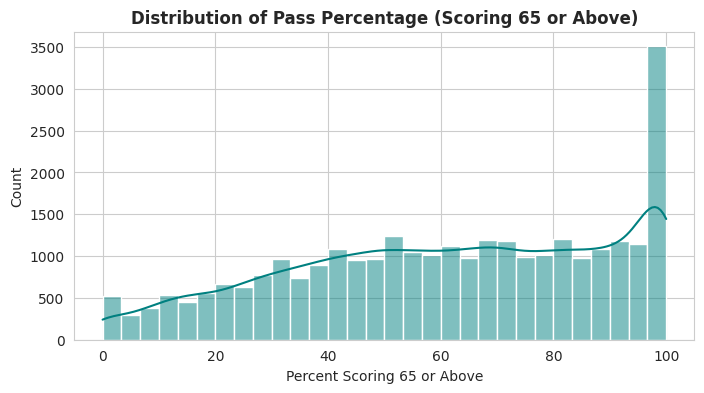

In [6]:
plt.figure(figsize=(8,4))
sns.histplot(data['Percent Scoring 65 or Above'], bins=30, kde=True, color='teal')
plt.title('Distribution of Pass Percentage (Scoring 65 or Above)',fontweight='bold')
plt.xlabel('Percent Scoring 65 or Above')
plt.show()


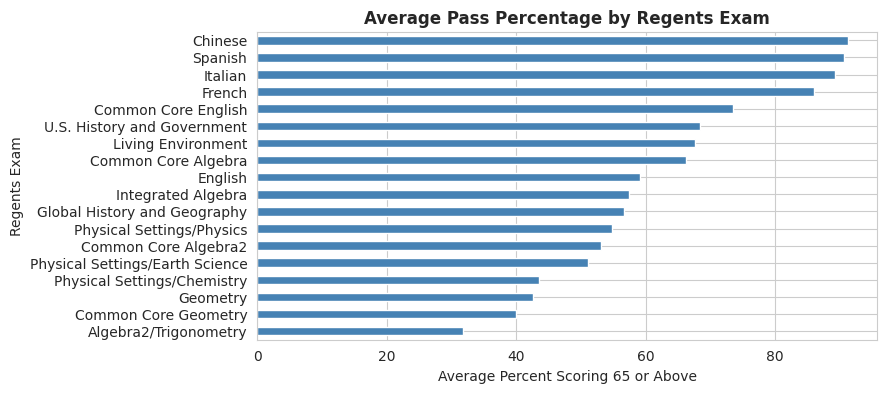

In [7]:
plt.figure(figsize=(8,4))
data.groupby('Regents Exam')['Percent Scoring 65 or Above'].mean().sort_values().plot(kind='barh', color='steelblue')
plt.title('Average Pass Percentage by Regents Exam',fontweight='bold')
plt.xlabel('Average Percent Scoring 65 or Above')
plt.show()


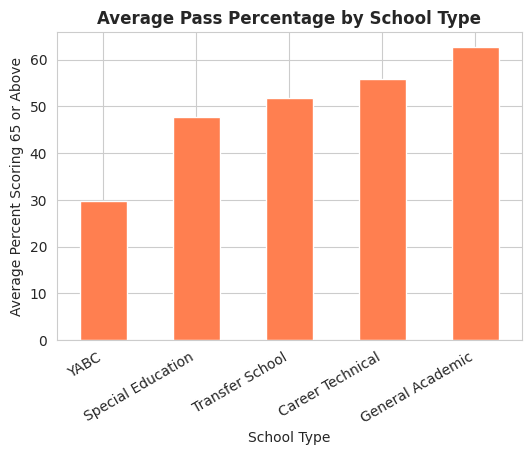

In [8]:
plt.figure(figsize=(6,4))
data.groupby('School Type')['Percent Scoring 65 or Above'].mean().sort_values().plot(kind='bar', color='coral')
plt.title('Average Pass Percentage by School Type',fontweight='bold')
plt.ylabel('Average Percent Scoring 65 or Above')
plt.xticks(rotation=30, ha='right')
plt.show()


## **6. Target Creation & Feature Selection**

**Target:** `Pass_Target` = 1 if a school-exam group's pass rate (`Percent Scoring 65 or Above`) is **≥ 65%**, else 0. This gives a nicely balanced binary classification problem.

**Avoiding data leakage:** We deliberately **exclude** all other score-derived columns (Mean Score, Number/Percent Scoring 65+, 80+, CR, Below 65) from the features — these are mathematically tied to the target and would leak the answer. We only use genuine "before the fact" metadata: school identity, school type/level, exam subject, year, and number of students tested.

In [9]:
data['Pass_Target'] = (data['Percent Scoring 65 or Above'] >= 65).astype(int)

print(data['Pass_Target'].value_counts(normalize=True).rename('proportion'))

features = ['School DBN', 'School Type', 'School Level', 'Regents Exam', 'Year', 'Total Tested']
X = data[features].copy()
y = data['Pass_Target']

# Encode categorical columns
encoders = {}
for col in ['School DBN', 'School Type', 'School Level', 'Regents Exam']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

X.head()


Pass_Target
0    0.524351
1    0.475649
Name: proportion, dtype: float64


,School DBN,School Type,School Level,Regents Exam,Year,Total Tested
1,2,1,4,12,2018,32.0
3,9,1,1,16,2017,16.0
4,34,1,1,8,2015,163.0
7,50,1,1,7,2019,21.0
8,56,1,1,6,2015,128.0


## **7. Train-Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (23424, 6)  Test size: (5856, 6)


## **8. Model Building**

We train three tree-based models (good defaults for tabular data) and compare them:
- **Random Forest** (with `class_weight='balanced'`)
- **XGBoost**
- **LightGBM** (with `class_weight='balanced'`)

In [11]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=6, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=300, class_weight='balanced', random_state=42, verbosity=-1)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results[name] = {"model": model, "accuracy": acc, "f1": f1, "preds": preds}
    print(f"{name}: Accuracy = {acc:.4f} | F1-score = {f1:.4f}")


Random Forest: Accuracy = 0.7917 | F1-score = 0.7779
XGBoost: Accuracy = 0.8321 | F1-score = 0.8218
LightGBM: Accuracy = 0.8265 | F1-score = 0.8186


## **9. Best Model Evaluation**

In [12]:
best_name = max(results, key=lambda k: results[k]['f1'])
best_model = results[best_name]['model']
best_preds = results[best_name]['preds']
print("Best model:", best_name)
print()
print(classification_report(y_test, best_preds, target_names=['Below 65 (Fail)', '65+ (Pass)']))


Best model: XGBoost

                 precision    recall  f1-score   support

Below 65 (Fail)       0.83      0.85      0.84      3071
     65+ (Pass)       0.83      0.81      0.82      2785

       accuracy                           0.83      5856
      macro avg       0.83      0.83      0.83      5856
   weighted avg       0.83      0.83      0.83      5856



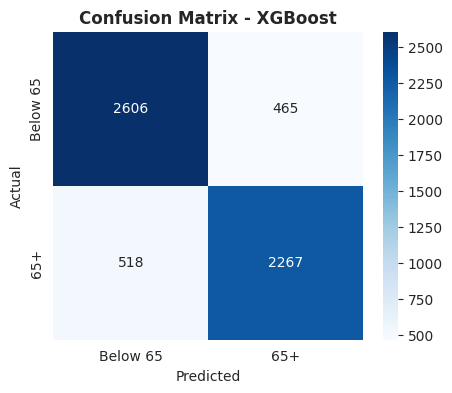

In [13]:
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Below 65','65+'], yticklabels=['Below 65','65+'])
plt.title(f'Confusion Matrix - {best_name}',fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## **10. Feature Importance**

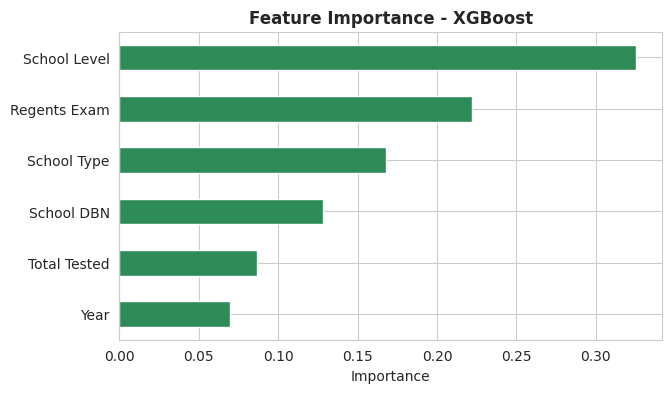

In [14]:
importances = pd.Series(best_model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(7,4))
importances.plot(kind='barh', color='seagreen')
plt.title(f'Feature Importance - {best_name}',fontweight='bold')
plt.xlabel('Importance')
plt.show()


## **11. Conclusion**

- We built a **leakage-free binary classifier** to predict whether a school's Regents exam pass rate is **≥65%**, using only pre-exam metadata (school identity, school type/level, subject, year, number tested).
- After cleaning suppressed (`'s'`) values, we worked with a clean, balanced dataset (~52% / 48% split), avoiding the need for artificial oversampling like SMOTE.
- Among Random Forest, XGBoost, and LightGBM, the **best model achieved ~83% accuracy and a comparable F1-score**, showing tree-based models handle this tabular, mixed-categorical data well.
- **School identity (`School DBN`)** and **Regents Exam subject** turned out to be the strongest predictors — confirming that a school's historical academic environment and the specific exam subject matter most for pass-rate outcomes, more so than the year or number of students tested.
- **Next steps:** engineering school-level historical trend features, adding borough/district groupings, or trying ensemble stacking could push performance further.

> ***Thanks for reading! If you found this useful, please upvote 🙂***
